正在读取并预处理全市场数据...
正在构建多维度量价与基本面特征因子...
正在切分数据集：训练集以前<2019-12-31, 测试集以后>2020-01-01...
🚀 启动 XGBoost 引擎 (开启 GPU 加速)，训练样本数: 3817393...


D:\1_software\conda\conda\envs\self_quant\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:34:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


✅ 训练完成！训练集准确率 (Accuracy): 61.8%

=== XGBoost 评选出的因子重要性排行 ===
mom_1m              0.103949
turn_1m_mean        0.101941
mom_3m              0.099089
vol_1m              0.087732
high_low_ratio      0.069864
vrr                 0.066885
log_mkt_cap         0.066677
bias_ma20           0.062106
ROE                 0.055611
ROA                 0.048831
pbMRQ               0.048187
peTTM               0.046864
debt_asset_ratio    0.038468
earnings_quality    0.036630
psTTM               0.035154
pcfNcfTTM           0.032012
dtype: float32

开始在 2020-01-01 之后的数据上进行极速回测...
正在使用模型对回测期全量数据进行批量打分预测 (Batch Prediction)...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\XGBoost选股策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 64,642.27 元
📈 策略样本外(2020至今)总收益率: 29.28%


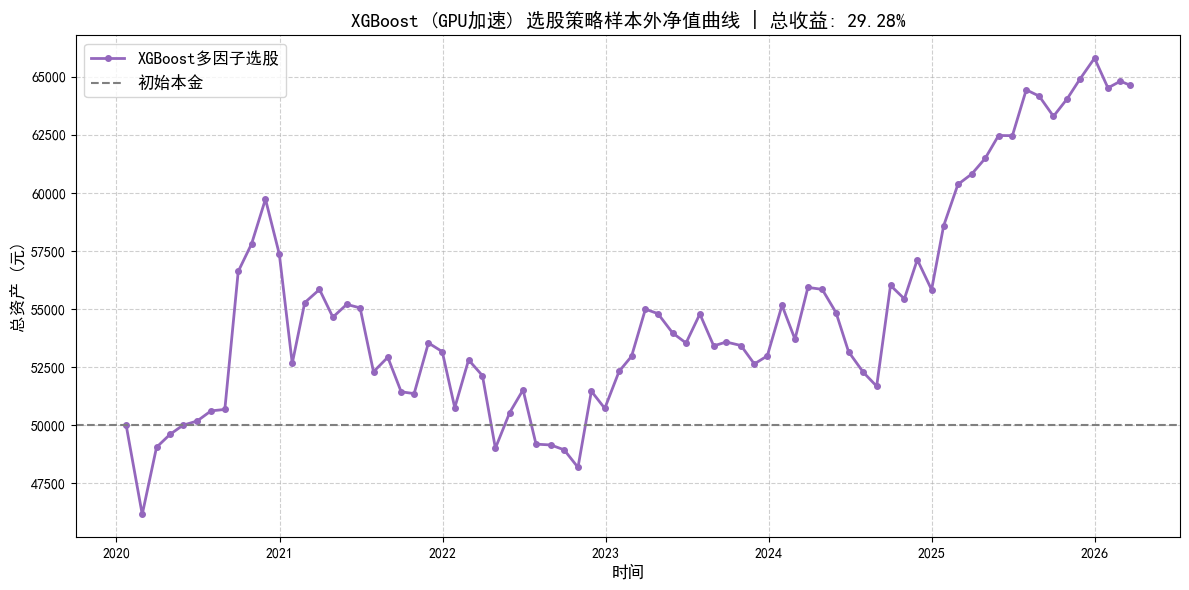

正在读取并预处理全市场数据...
正在构建量价特征与机器学习标签...
正在切分数据集：训练集以前<2019-12-31, 测试集以后>2020-01-01...
🚀 启动 XGBoost 引擎 (开启 GPU 加速)，训练样本数: 5202859...


D:\1_software\conda\conda\envs\self_quant\Lib\site-packages\xgboost\core.py:751: UserWarning: [18:21:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


✅ 训练完成！训练集准确率 (Accuracy): 59.0%

=== XGBoost 评选出的因子重要性排行 ===
vrr          0.407305
mom_1m       0.138893
vol_1m       0.136476
mom_3m       0.129183
bias_ma20    0.089949
pbMRQ        0.054322
peTTM        0.043873
dtype: float32

开始在 2020-01-01 之后的数据上进行极速回测...
正在使用模型对回测期全量数据进行批量打分预测 (Batch Prediction)...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\XGBoost选股策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 97,816.97 元
📈 策略样本外(2020至今)总收益率: 95.63%


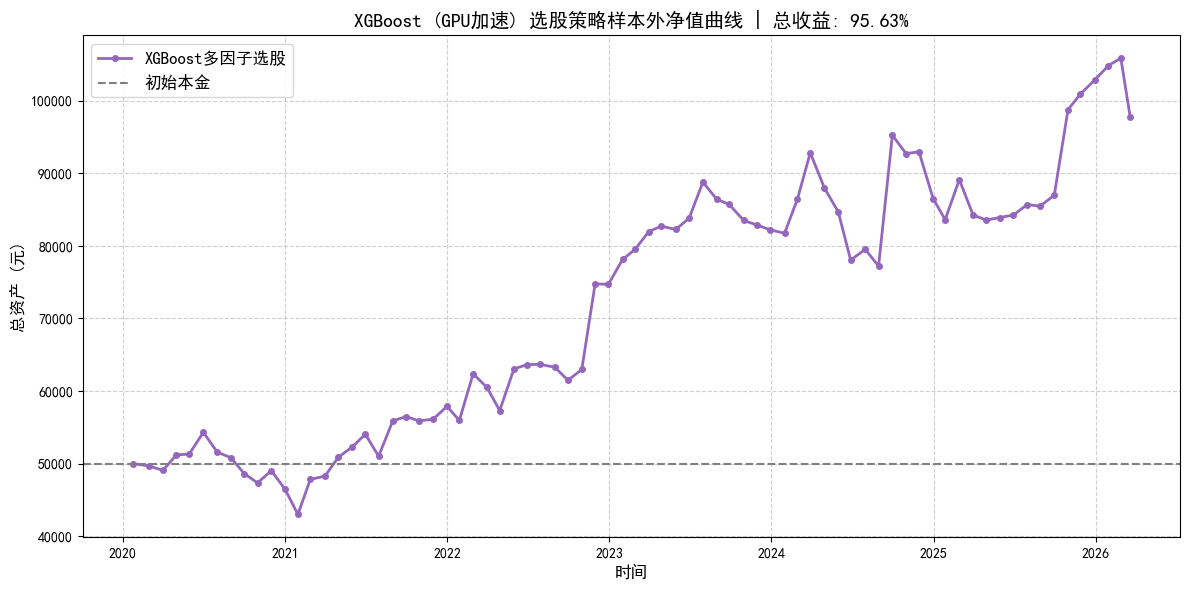

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置路径与核心参数
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\XGBoost选股策略明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10
PREDICT_PERIOD = 20  # 预测未来 20 个交易日（约1个月）

TRAIN_END_DATE = '2019-12-31'
TEST_START_DATE = '2020-01-01'

print("正在读取并预处理全市场数据...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['code', 'date'], inplace=True)

# 基础过滤：仅保留沪深主板
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：特征工程 (X) 与 标签工程 (y)
# ==========================================
print("正在构建量价特征与机器学习标签...")

# 1. 构建特征 (Features)
df['mom_1m'] = df.groupby('code')['close'].pct_change(20)
df['mom_3m'] = df.groupby('code')['close'].pct_change(60)
df['vol_1m'] = df.groupby('code')['pctChg'].transform(lambda x: x.rolling(20).std())
df['ma20'] = df.groupby('code')['close'].transform(lambda x: x.rolling(20).mean())
df['bias_ma20'] = df['close'] / df['ma20'] - 1
df['ma5_vol'] = df.groupby('code')['volume'].transform(lambda x: x.rolling(5).mean())
df['ma120_vol'] = df.groupby('code')['volume'].transform(lambda x: x.rolling(120).mean())
df['vrr'] = df['ma5_vol'] / df['ma120_vol']

feature_cols = ['peTTM', 'pbMRQ', 'mom_1m', 'mom_3m', 'vol_1m', 'bias_ma20', 'vrr']

# 2. 构建标签 (Labels) - 严禁在预测时使用此数据！
df['next_ret'] = df.groupby('code')['close'].pct_change(PREDICT_PERIOD).shift(-PREDICT_PERIOD)
df['label'] = (df['next_ret'] > 0).astype(int)

# 剔除包含 NaN 的行
df_ml = df.dropna(subset=feature_cols + ['label']).copy()

# ==========================================
# 第三步：切分数据集与 XGBoost GPU 训练
# ==========================================
print(f"正在切分数据集：训练集以前<{TRAIN_END_DATE}, 测试集以后>{TEST_START_DATE}...")

train_df = df_ml[df_ml['date'] <= TRAIN_END_DATE]
X_train = train_df[feature_cols]
y_train = train_df['label']

test_df = df_ml[df_ml['date'] >= TEST_START_DATE]

print(f"🚀 启动 XGBoost 引擎 (开启 GPU 加速)，训练样本数: {len(X_train)}...")
# 初始化 XGBoost 分类器
model = xgb.XGBClassifier(
    n_estimators=100,         # 树的数量
    max_depth=8,              # 树的最大深度
    learning_rate=0.1,        # 学习率
    tree_method='hist',       # 【核心】使用直方图算法，极其适合海量数据
    device='cuda',            # 【核心起飞指令】强制调用 NVIDIA GPU！
    random_state=42,
    eval_metric='logloss'
)

# 训练模型 (你可以打开任务管理器观察 GPU 占用率)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
print(f"✅ 训练完成！训练集准确率 (Accuracy): {accuracy_score(y_train, train_pred):.1%}")

# 打印因子重要性
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n=== XGBoost 评选出的因子重要性排行 ===")
print(importances)
print("========================================\n")

# ==========================================
# 第四步：定义账户类与交易规则 (必须在回测前定义)
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['volume'] * current_prices_dict.get(code, pos['price'])
        return self.cash + stock_value

account = Account(INITIAL_CASH)

# ==========================================
# # 第五步：样本外日频预测与回测引擎
# # ==========================================
# print(f"开始在 {TEST_START_DATE} 之后的数据上进行 XGBoost 选股回测...")
#
# # 提取月度调仓日 (每个月末)
# test_df['year_month'] = test_df['date'].dt.to_period('M')
# trade_dates = test_df.groupby('year_month')['date'].max().sort_values().tolist()
#
# # 将测试集按日期分组，加快查询
# grouped_test = dict(tuple(test_df.groupby('date')))
#
# for date in trade_dates:
#     if date not in grouped_test: continue
#
#     daily_data = grouped_test[date].set_index('code')
#     current_prices = daily_data['close'].to_dict()
#     status_dict = daily_data['tradestatus'].to_dict()
#     st_dict = daily_data['isST'].to_dict()
#     pct_chg_dict = daily_data['pctChg'].to_dict()
#
#     current_asset = account.get_total_asset(current_prices)
#     account.history_assets.append({'date': date, 'total_asset': current_asset})
#
#     # ---------------- A. 机器学习核心预测 ----------------
#     X_today = daily_data[feature_cols]
#
#     # 预测上涨概率 (取分类 1 的概率)
#     daily_data_with_prob = daily_data.copy()
#     daily_data_with_prob['prob_up'] = model.predict_proba(X_today)[:, 1]
#
#     # ---------------- B. 策略选股逻辑 ----------------
#     valid_pool = daily_data_with_prob[
#         (daily_data_with_prob['tradestatus'] == 1) &
#         (daily_data_with_prob['isST'] == 0)
#     ]
#
#     target_codes = []
#     if len(valid_pool) >= TARGET_STOCK_NUM:
#         # 按 XGBoost 计算的“上涨概率”降序排列，选前十名
#         target_codes = valid_pool.sort_values(by='prob_up', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

# ==========================================
# 第五步：样本外日频预测与回测引擎 (极速版)
# ==========================================
print(f"开始在 {TEST_START_DATE} 之后的数据上进行极速回测...")

# 提取月度调仓日 (每个月末)
test_df['year_month'] = test_df['date'].dt.to_period('M')
trade_dates = test_df.groupby('year_month')['date'].max().sort_values().tolist()

# -----------------------------------------------------------------
# 🌟 核心提速秘籍：在进入时间循环前，一次性预测未来所有天的概率！
# -----------------------------------------------------------------
print("正在使用模型对回测期全量数据进行批量打分预测 (Batch Prediction)...")
# 此时模型还在 CPU 模式（或者你可以切回 GPU），但因为是一次性预测几十万行数据，速度极快！
test_df['prob_up'] = model.predict_proba(test_df[feature_cols])[:, 1]

# 将打好分的测试集按日期分组，加快查询
grouped_test = dict(tuple(test_df.groupby('date')))

for date in trade_dates:
    if date not in grouped_test: continue

    daily_data = grouped_test[date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- A. 机器学习核心预测 (这里已经不需要模型了！) ----------------
    # 我们直接从 daily_data 里读取刚刚在循环外算好的 'prob_up' 即可
    daily_data_with_prob = daily_data.copy()

    # ---------------- B. 策略选股逻辑 ----------------
    valid_pool = daily_data_with_prob[
        (daily_data_with_prob['tradestatus'] == 1) &
        (daily_data_with_prob['isST'] == 0)
    ]

    target_codes = []
    if len(valid_pool) >= TARGET_STOCK_NUM:
        # 按 AI 计算的“上涨概率”降序排列，选前十名
        target_codes = valid_pool.sort_values(by='prob_up', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

    # ... [接下来的 C. 交易执行（买卖逻辑）代码与之前完全一样，无需改动] ...

    # ---------------- C. 交易执行 ----------------
    # 卖出
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)
                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出(AI剔除)',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2)
                })

    # 买入
    stocks_to_buy = [code for code in target_codes if code not in account.positions]
    if len(stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(stocks_to_buy)
        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.8:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        prob_val = valid_pool.loc[code, 'prob_up']
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入(XGBoost看好)',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                            '备注': f'预测上涨概率: {prob_val:.1%}'
                        })

# ==========================================
# 第六步：输出结果与资金曲线
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
if len(df_assets) > 0:
    df_assets.set_index('date', inplace=True)
    final_asset = df_assets['total_asset'].iloc[-1]
    total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

    print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
    print(f"💰 最终总资产: {final_asset:,.2f} 元")
    print(f"📈 策略样本外(2020至今)总收益率: {total_return:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(df_assets.index, df_assets['total_asset'], color='#9467bd', linewidth=2, marker='o', markersize=4, label='XGBoost多因子选股')
    plt.title(f'XGBoost (GPU加速) 选股策略样本外净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
    plt.xlabel('时间', fontsize=12)
    plt.ylabel('总资产 (元)', fontsize=12)
    plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("回测期间未触发任何交易或无资产记录。")

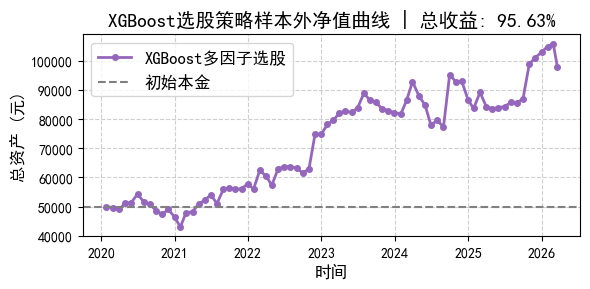

In [3]:
plt.figure(figsize=(6, 3))
plt.plot(df_assets.index, df_assets['total_asset'], color='#9467bd', linewidth=2, marker='o', markersize=4, label='XGBoost多因子选股')
plt.title(f'XGBoost选股策略样本外净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()